# Task 1: Data Foundations

This section explores NumPy and PyTorch basics, including tensor creation, reshaping, and arithmetic operations.

In [ ]:
import numpy as np
import torch

In [ ]:
# Creating NumPy arrays
a = np.array([1, 2, 3, 4])
b = np.array([[1, 2], [3, 4]])

print("Array a:")
print(a)
print("Shape of a:", a.shape)

print("\nArray b:")
print(b)
print("Shape of b:", b.shape)

Array a:
[1 2 3 4]
Shape of a: (4,)

Array b:
[[1 2]
 [3 4]]
Shape of b: (2, 2)


Observation: NumPy arrays are useful for storing and manipulating numerical data. The shape tells us the dimensions of the array.

In [ ]:
# Creating PyTorch tensors
x = torch.tensor([1, 2, 3, 4])
y = torch.tensor([[1, 2], [3, 4]])

print("Tensor x:")
print(x)
print("Shape of x:", x.shape)

print("\nTensor y:")
print(y)
print("Shape of y:", y.shape)

Tensor x:
tensor([1, 2, 3, 4])
Shape of x: torch.Size([4])

Tensor y:
tensor([[1, 2],
        [3, 4]])
Shape of y: torch.Size([2, 2])


Observation: PyTorch tensors are similar to NumPy arrays, but they are designed for deep learning and can be used directly in neural network models.

In [ ]:
# Reshaping tensors
tensor1 = torch.arange(12)
print("Original tensor:")
print(tensor1)
print("Original shape:", tensor1.shape)

reshaped_tensor = tensor1.reshape(3, 4)
print("\nReshaped tensor:")
print(reshaped_tensor)
print("Reshaped shape:", reshaped_tensor.shape)

Original tensor:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Original shape: torch.Size([12])

Reshaped tensor:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Reshaped shape: torch.Size([3, 4])


Observation: Reshaping changes the dimensions of the tensor without changing its values. This is important when preparing data for machine learning models.

In [ ]:
# Arithmetic operations
t1 = torch.tensor([1, 2, 3])
t2 = torch.tensor([4, 5, 6])

print("Addition:", t1 + t2)
print("Subtraction:", t1 - t2)
print("Multiplication:", t1 * t2)
print("Division:", t2 / t1)

Addition: tensor([5, 7, 9])
Subtraction: tensor([-3, -3, -3])
Multiplication: tensor([ 4, 10, 18])
Division: tensor([4.0000, 2.5000, 2.0000])


In [ ]:
# Matrix multiplication
m1 = torch.tensor([[1, 2], [3, 4]])
m2 = torch.tensor([[5, 6], [7, 8]])

result = torch.matmul(m1, m2)

print("Matrix 1:")
print(m1)

print("\nMatrix 2:")
print(m2)

print("\nMatrix Multiplication Result:")
print(result)

Matrix 1:
tensor([[1, 2],
        [3, 4]])

Matrix 2:
tensor([[5, 6],
        [7, 8]])

Matrix Multiplication Result:
tensor([[19, 22],
        [43, 50]])


Observation: Matrix multiplication is a core operation in deep learning because neural networks use it to combine inputs with weights.

In [ ]:
# Converting NumPy array to PyTorch tensor
np_array = np.array([10, 20, 30])
torch_tensor = torch.from_numpy(np_array)

print("NumPy array:", np_array)
print("Converted PyTorch tensor:", torch_tensor)

NumPy array: [10 20 30]
Converted PyTorch tensor: tensor([10, 20, 30])


Observation: NumPy arrays can be converted into PyTorch tensors easily, which is helpful when moving from general data analysis into deep learning tasks.

## Reflection

In this task, I practiced creating NumPy arrays and PyTorch tensors, checking their shapes, reshaping them, and applying arithmetic and matrix operations. I learned that PyTorch tensors are very similar to NumPy arrays, but they are more suitable for deep learning because they work directly with neural network models. Understanding these basics is important because tensors are the main data structure used in machine learning and deep learning.

**Task 2- Text Augmentation Using Amazon Reviews Dataset**

In [ ]:
import pandas as pd
import re
import random

In [ ]:
df = pd.read_csv("Amazon_Reviews.csv", engine="python", on_bad_lines="skip")
print(df.shape)
print(df.columns)
df.head()

(21214, 9)
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)              # remove html tags
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)     # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces
    return text

df = df.dropna(subset=["Review Text"]).copy()
df["Cleaned_Review"] = df["Review Text"].apply(clean_text)

# remove very short reviews
df = df[df["Cleaned_Review"].str.len() > 20].reset_index(drop=True)

print(df[["Review Text", "Cleaned_Review"]].head())

                                         Review Text  \
0  I registered on the website, tried to order a ...   
1  Had multiple orders one turned up and driver h...   
2  I informed these reprobates that I WOULD NOT B...   
3  I have bought from Amazon before and no proble...   
4  If I could give a lower rate I would! I cancel...   

                                      Cleaned_Review  
0  i registered on the website tried to order a l...  
1  had multiple orders one turned up and driver h...  
2  i informed these reprobates that i would not b...  
3  i have bought from amazon before and no proble...  
4  if i could give a lower rate i would i cancell...  


### Observation
I cleaned the review text by converting it to lowercase, removing punctuation, removing extra spaces, and dropping missing values. This step is important because text augmentation works better on consistent and clean input data.

In [ ]:
sample_df = df.sample(10, random_state=42).copy()
sample_df[["Review Title", "Cleaned_Review"]]

,Review Title,Cleaned_Review
19193,Good prices,all went fine and i got my stuff in denmark lo...
9577,FAULTY GIFT CARD,i was given an amazon gift card for my birthda...
7048,Customer Service won't help,customer service wont help amazon sent me some...
20816,Excellent!,have used amazon on several occasions when buy...
12584,Amazon sellers ruin Amazon reputation,amazon is not what it was it turns out amazon ...
563,I Have been an Amazon customer for many…,i have been an amazon customer for many years ...
16094,Dodgy website selling cheap junk and…,dodgy website selling cheap junk and inferior ...
10532,The packaging arrives open,the packaging arrives open some products and n...
9983,Shady company,review text not found
14533,Unfortunately Not Great,unfortunately due to their contracted delivery...


In [ ]:
synonyms = {
    "good": "great",
    "bad": "poor",
    "fast": "quick",
    "slow": "sluggish",
    "easy": "simple",
    "hard": "difficult",
    "happy": "pleased",
    "terrible": "awful",
    "product": "item",
    "service": "support",
    "buy": "purchase",
    "help": "assist",
    "problem": "issue",
    "order": "purchase",
    "wait": "delay"
}

def synonym_replacement(text):
    words = text.split()
    new_words = [synonyms.get(word, word) for word in words]
    return " ".join(new_words)

def random_swap(text):
    words = text.split()
    if len(words) < 2:
        return text
    words = words[:]
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return " ".join(words)

def random_deletion(text, p=0.15):
    words = text.split()
    if len(words) <= 1:
        return text
    kept_words = [word for word in words if random.random() > p]
    if len(kept_words) == 0:
        kept_words = [random.choice(words)]
    return " ".join(kept_words)

def augment_text(text):
    method = random.choice(["synonym", "swap", "deletion"])
    if method == "synonym":
        return synonym_replacement(text), "Synonym Replacement"
    elif method == "swap":
        return random_swap(text), "Random Swap"
    else:
        return random_deletion(text), "Random Deletion"

In [ ]:
augmented_reviews = sample_df["Cleaned_Review"].apply(augment_text)

sample_df["Augmented_Review"] = augmented_reviews.apply(lambda x: x[0])
sample_df["Transformation"] = augmented_reviews.apply(lambda x: x[1])

sample_df[["Review Title", "Cleaned_Review", "Augmented_Review", "Transformation"]]

,Review Title,Cleaned_Review,Augmented_Review,Transformation
19193,Good prices,all went fine and i got my stuff in denmark lo...,went fine got my stuff love all the amazon sit...,Random Deletion
9577,FAULTY GIFT CARD,i was given an amazon gift card for my birthda...,i was given an amazon gift card for my birthda...,Synonym Replacement
7048,Customer Service won't help,customer service wont help amazon sent me some...,customer service wont help amazon sent me some...,Random Swap
20816,Excellent!,have used amazon on several occasions when buy...,have used amazon on occasions when things only...,Random Deletion
12584,Amazon sellers ruin Amazon reputation,amazon is not what it was it turns out amazon ...,amazon is not what was it turns amazon has no ...,Random Deletion
563,I Have been an Amazon customer for many…,i have been an amazon customer for many years ...,i have been an amazon customer for many years ...,Synonym Replacement
16094,Dodgy website selling cheap junk and…,dodgy website selling cheap junk and inferior ...,dodgy website selling cheap junk and inferior ...,Synonym Replacement
10532,The packaging arrives open,the packaging arrives open some products and n...,the packaging arrives open some products and n...,Random Swap
9983,Shady company,review text not found,review text not,Random Deletion
14533,Unfortunately Not Great,unfortunately due to their contracted delivery...,unfortunately due to their contracted delivery...,Random Swap


In [ ]:
for i, row in sample_df.reset_index(drop=True).iterrows():
    print(f"Review {i+1}")
    print("Title:", row["Review Title"])
    print("Original:", row["Cleaned_Review"])
    print("Augmented:", row["Augmented_Review"])
    print("Transformation:", row["Transformation"])
    print("-" * 100)

Review 1
Title: Good prices
Original: all went fine and i got my stuff in denmark love all the amazon sites and already used com couk and de i really hope to see a dk at some point
Augmented: went fine got my stuff love all the amazon sites and already used com couk and de i really hope see a dk at point
Transformation: Random Deletion
----------------------------------------------------------------------------------------------------
Review 2
Title: FAULTY GIFT CARD
Original: i was given an amazon gift card for my birthday i was the one who opened it and removed the sticker the code that is supposed to redeem the gift card did not work so i emailed amazon and they are claiming the gift card was already used this is impossible unless there was a flaw in creating the gift card and they are reusing numbers very annoyed with amazon would not recommend buying an amazon gift card
Augmented: i was given an amazon gift card for my birthday i was the one who opened it and removed the sticker t

## Task 2 Observations

For this task, I used the Amazon Reviews dataset and selected 10 random reviews from the `Review Text` column. Before augmentation, I cleaned the text by removing punctuation, converting all letters to lowercase, removing extra spaces, and excluding missing values.

I then applied text augmentation techniques such as synonym replacement, random word swap, and random deletion. Synonym replacement changed some words to similar words while keeping the general meaning. Random swap changed the order of two words, which created variation in sentence structure. Random deletion removed a few words, making the sentence shorter but still understandable in most cases.

These transformations help increase dataset diversity and can improve model generalization by exposing a model to slightly different versions of the same text.

In [ ]:
final_task2 = sample_df[["Review Title", "Cleaned_Review", "Augmented_Review", "Transformation"]]
final_task2

,Review Title,Cleaned_Review,Augmented_Review,Transformation
19193,Good prices,all went fine and i got my stuff in denmark lo...,went fine got my stuff love all the amazon sit...,Random Deletion
9577,FAULTY GIFT CARD,i was given an amazon gift card for my birthda...,i was given an amazon gift card for my birthda...,Synonym Replacement
7048,Customer Service won't help,customer service wont help amazon sent me some...,customer service wont help amazon sent me some...,Random Swap
20816,Excellent!,have used amazon on several occasions when buy...,have used amazon on occasions when things only...,Random Deletion
12584,Amazon sellers ruin Amazon reputation,amazon is not what it was it turns out amazon ...,amazon is not what was it turns amazon has no ...,Random Deletion
563,I Have been an Amazon customer for many…,i have been an amazon customer for many years ...,i have been an amazon customer for many years ...,Synonym Replacement
16094,Dodgy website selling cheap junk and…,dodgy website selling cheap junk and inferior ...,dodgy website selling cheap junk and inferior ...,Synonym Replacement
10532,The packaging arrives open,the packaging arrives open some products and n...,the packaging arrives open some products and n...,Random Swap
9983,Shady company,review text not found,review text not,Random Deletion
14533,Unfortunately Not Great,unfortunately due to their contracted delivery...,unfortunately due to their contracted delivery...,Random Swap


**Task 3: Image Augmentation**

In [ ]:
import zipfile
import os
import random
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

In [ ]:
zip_path = "archive (1).zip"
extract_path = "cifar10_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
image_paths = []

base_folder = os.path.join(extract_path, "cifar10")

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))
print("Sample path:", image_paths[0])

Total images found: 60000
Sample path: cifar10_data/cifar10/test/frog/0126.png


In [ ]:
random.seed(42)
sample_paths = random.sample(image_paths, 10)

for path in sample_paths:
    print(path)

cifar10_data/cifar10/train/horse/0140.png
cifar10_data/cifar10/test/cat/0316.png
cifar10_data/cifar10/test/airplane/0499.png
cifar10_data/cifar10/train/cat/4244.png
cifar10_data/cifar10/train/airplane/0922.png
cifar10_data/cifar10/train/airplane/2460.png
cifar10_data/cifar10/train/frog/3002.png
cifar10_data/cifar10/test/bird/0383.png
cifar10_data/cifar10/train/cat/4683.png
cifar10_data/cifar10/test/horse/0741.png


In [ ]:
random_crop = transforms.RandomCrop(32, padding=4)
horizontal_flip = transforms.RandomHorizontalFlip(p=1.0)   # always flip so it is visible
rotation = transforms.RandomRotation(20)
color_jitter = transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4)

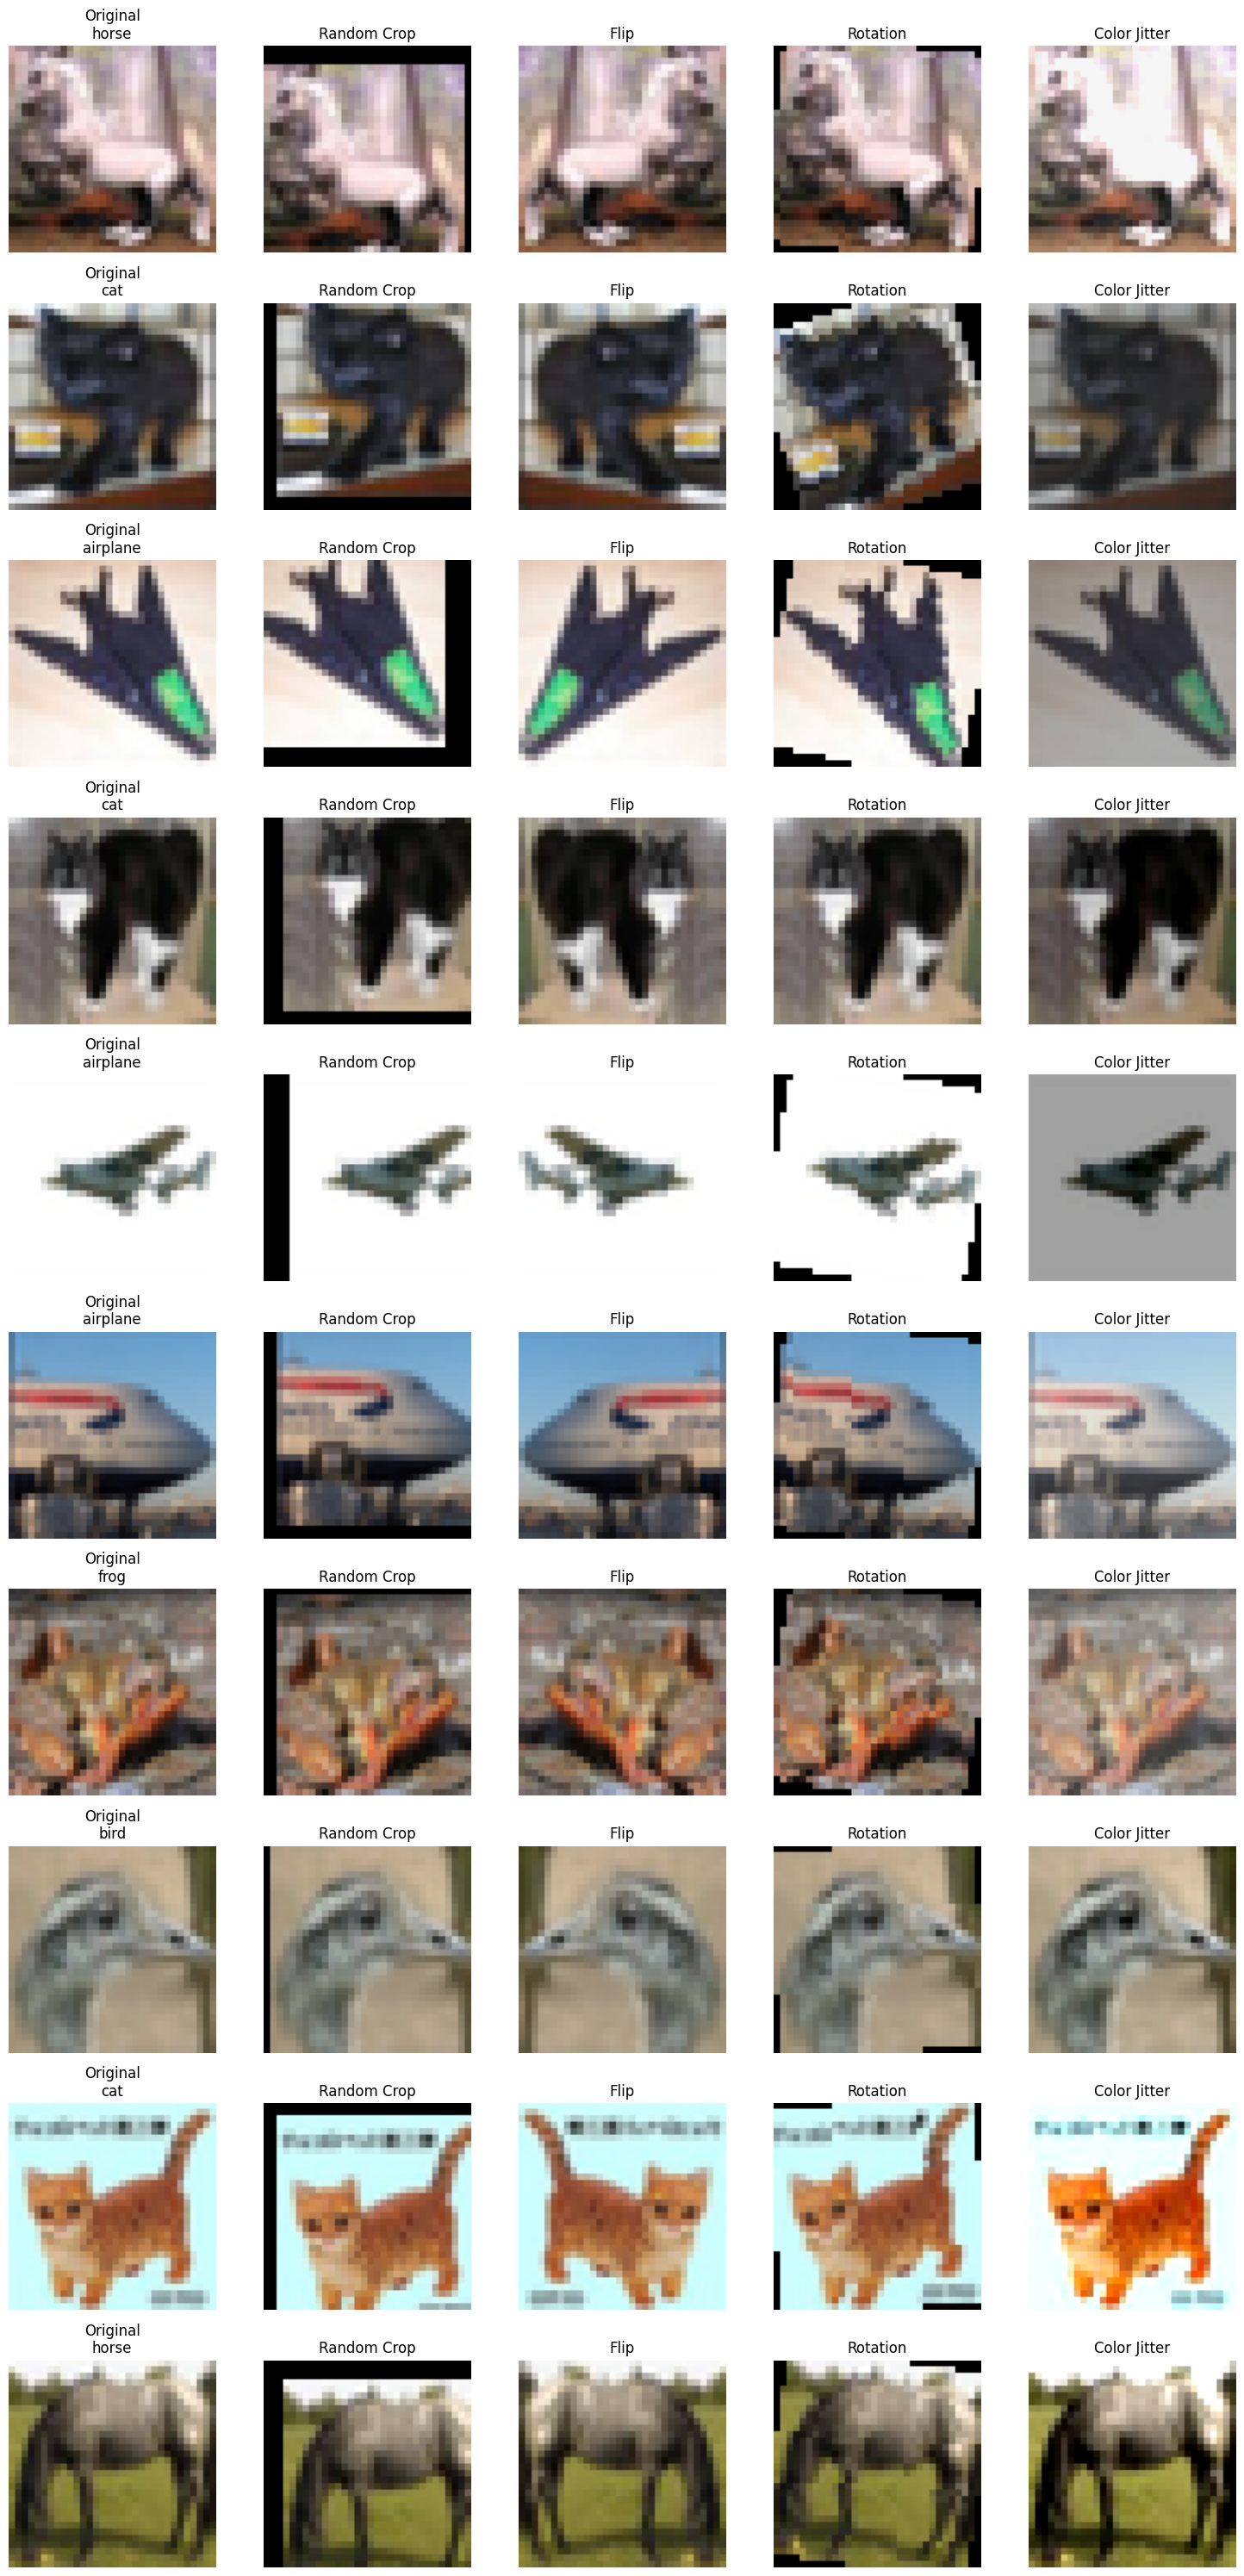

In [ ]:
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path).convert("RGB")

    crop_img = random_crop(img)
    flip_img = horizontal_flip(img)
    rotate_img = rotation(img)
    jitter_img = color_jitter(img)

    # enlarge for display only
    img_display = img.resize((96, 96), Image.NEAREST)
    crop_display = crop_img.resize((96, 96), Image.NEAREST)
    flip_display = flip_img.resize((96, 96), Image.NEAREST)
    rotate_display = rotate_img.resize((96, 96), Image.NEAREST)
    jitter_display = jitter_img.resize((96, 96), Image.NEAREST)

    label = os.path.basename(os.path.dirname(img_path))

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Original\n{label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(crop_display)
    axes[i, 1].set_title("Random Crop")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(flip_display)
    axes[i, 2].set_title("Flip")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(rotate_display)
    axes[i, 3].set_title("Rotation")
    axes[i, 3].axis("off")

    axes[i, 4].imshow(jitter_display)
    axes[i, 4].set_title("Color Jitter")
    axes[i, 4].axis("off")

plt.tight_layout()
plt.show()

# Task 3: Image Augmentation Using CIFAR-10

For this task, I loaded 10 random images from the CIFAR-10 dataset and applied several image augmentation techniques. The transformations used were random crop, horizontal flip, rotation, and color jitter.

Random crop changes the image framing slightly by shifting the visible area. Horizontal flip mirrors the image from left to right. Rotation changes the viewing angle, while color jitter adjusts brightness, contrast, and saturation. These transformations create variations in the dataset while still preserving the main object in the image.

Image augmentation is useful because it increases data diversity and helps models generalize better. A model trained with augmented data is usually more robust to changes in position, lighting, and orientation in real-world images.

### Observation

The augmented images remained recognizable, but their position, orientation, and color appearance changed. This shows how augmentation can simulate real-world variation and improve model robustness.

**Task 4: MLP Scaling Experiment**

In [ ]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

In [ ]:
train_indices = list(range(5000))
test_indices = list(range(1000))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Using device: cpu


In [ ]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
full_test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

# Fixed 1,000 test samples
test_dataset_mnist = Subset(full_test_dataset, range(1000))
test_loader_mnist = DataLoader(test_dataset_mnist, batch_size=64, shuffle=False)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


def train_mlp(train_loader, test_loader, epochs=5):
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    train_acc = evaluate_model(model, train_loader)
    test_acc = evaluate_model(model, test_loader)

    return model, train_acc, test_acc

In [ ]:
dataset_sizes = [1000, 3000, 5000, 10000]
mnist_train_accs = []
mnist_test_accs = []

for size in dataset_sizes:
    train_subset = Subset(full_train_dataset, range(size))
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)

    model, train_acc, test_acc = train_mlp(train_loader, test_loader_mnist, epochs=5)

    mnist_train_accs.append(train_acc)
    mnist_test_accs.append(test_acc)

    print(f"MNIST Size: {size} | Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")

MNIST Size: 1000 | Train Accuracy: 85.60% | Test Accuracy: 77.60%
MNIST Size: 3000 | Train Accuracy: 93.07% | Test Accuracy: 87.70%
MNIST Size: 5000 | Train Accuracy: 92.86% | Test Accuracy: 87.50%
MNIST Size: 10000 | Train Accuracy: 94.29% | Test Accuracy: 90.40%


In [ ]:
# Use a class-balanced subset instead of the first N files.
# ImageFolder stores files class-by-class, so range(5000) would mostly select one class.

from collections import Counter

def stratified_subset_indices(dataset, samples_per_class, seed=42):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    selected_indices = []

    for class_id in np.unique(targets):
        class_indices = np.where(targets == class_id)[0]
        chosen = rng.choice(class_indices, size=samples_per_class, replace=False)
        selected_indices.extend(chosen.tolist())

    rng.shuffle(selected_indices)
    return selected_indices

# 5,000 training samples total = 500 per class across 10 classes
# 1,000 test samples total = 100 per class across 10 classes
train_indices = stratified_subset_indices(train_dataset_no_aug, samples_per_class=500, seed=42)
test_indices = stratified_subset_indices(test_dataset_cifar, samples_per_class=100, seed=42)

train_subset_no_aug = Subset(train_dataset_no_aug, train_indices)
train_subset_aug = Subset(train_dataset_aug, train_indices)
train_subset_eval = Subset(train_dataset_eval, train_indices)
test_subset_cifar = Subset(test_dataset_cifar, test_indices)

train_loader_no_aug = DataLoader(train_subset_no_aug, batch_size=128, shuffle=True)
train_loader_aug = DataLoader(train_subset_aug, batch_size=128, shuffle=True)

# Evaluation loaders
train_loader_eval = DataLoader(train_subset_eval, batch_size=128, shuffle=False)
test_loader_cifar = DataLoader(test_subset_cifar, batch_size=128, shuffle=False)

# Quick sanity check: each class should appear equally often
train_targets = np.array(train_dataset_no_aug.targets)[train_indices]
test_targets = np.array(test_dataset_cifar.targets)[test_indices]

train_distribution = {train_dataset_no_aug.classes[i]: int((train_targets == i).sum()) for i in range(len(train_dataset_no_aug.classes))}
test_distribution = {test_dataset_cifar.classes[i]: int((test_targets == i).sum()) for i in range(len(test_dataset_cifar.classes))}

print("Balanced CIFAR-10 training subset distribution:", train_distribution)
print("Balanced CIFAR-10 test subset distribution:", test_distribution)
print("Training samples:", len(train_subset_no_aug))
print("Test samples:", len(test_subset_cifar))

Balanced CIFAR-10 training subset distribution: {'airplane': 500, 'automobile': 500, 'bird': 500, 'cat': 500, 'deer': 500, 'dog': 500, 'frog': 500, 'horse': 500, 'ship': 500, 'truck': 500}
Balanced CIFAR-10 test subset distribution: {'airplane': 100, 'automobile': 100, 'bird': 100, 'cat': 100, 'deer': 100, 'dog': 100, 'frog': 100, 'horse': 100, 'ship': 100, 'truck': 100}
Training samples: 5000
Test samples: 1000


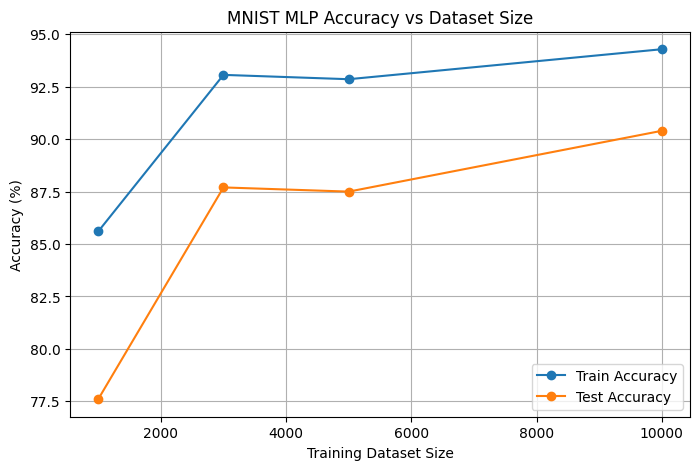

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, mnist_train_accs, marker='o', label='Train Accuracy')
plt.plot(dataset_sizes, mnist_test_accs, marker='o', label='Test Accuracy')
plt.xlabel("Training Dataset Size")
plt.ylabel("Accuracy (%)")
plt.title("MNIST MLP Accuracy vs Dataset Size")
plt.legend()
plt.grid(True)
plt.show()

Part B: CIFAR-10 Augmentation Experiment

In [ ]:
zip_path = "archive (1).zip"
extract_path = "cifar10_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
cifar_train_transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
train_dir = os.path.join(extract_path, "cifar10", "train")
test_dir = os.path.join(extract_path, "cifar10", "test")

train_dataset_no_aug = ImageFolder(train_dir, transform=cifar_train_transform_no_aug)
train_dataset_aug = ImageFolder(train_dir, transform=cifar_train_transform_aug)

# evaluation train set without augmentation
train_dataset_eval = ImageFolder(train_dir, transform=cifar_train_transform_no_aug)

test_dataset_cifar = ImageFolder(test_dir, transform=cifar_test_transform)

print("Train images:", len(train_dataset_no_aug))
print("Test images:", len(test_dataset_cifar))
print("Classes:", train_dataset_no_aug.classes)

Train images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
train_indices = list(range(5000))
test_indices = list(range(1000))

train_subset_no_aug = Subset(train_dataset_no_aug, train_indices)
train_subset_aug = Subset(train_dataset_aug, train_indices)
train_subset_eval = Subset(train_dataset_eval, train_indices)
test_subset_cifar = Subset(test_dataset_cifar, test_indices)

train_loader_no_aug = DataLoader(train_subset_no_aug, batch_size=128, shuffle=True)
train_loader_aug = DataLoader(train_subset_aug, batch_size=128, shuffle=True)

# evaluation loader for train accuracy
train_loader_eval = DataLoader(train_subset_eval, batch_size=128, shuffle=False)
test_loader_cifar = DataLoader(test_subset_cifar, batch_size=128, shuffle=False)

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def evaluate_cnn(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


def train_cnn(train_loader, train_eval_loader, test_loader, epochs=5):
    model = SmallCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    train_acc = evaluate_cnn(model, train_eval_loader)
    test_acc = evaluate_cnn(model, test_loader)

    return model, train_acc, test_acc

In [ ]:
model_no_aug, cifar_train_acc_no_aug, cifar_test_acc_no_aug = train_cnn(
    train_loader_no_aug,
    train_loader_eval,
    test_loader_cifar,
    epochs=5
)

print(f"No Augmentation -> Train Accuracy: {cifar_train_acc_no_aug:.2f}% | Test Accuracy: {cifar_test_acc_no_aug:.2f}%")

No Augmentation -> Train Accuracy: 100.00% | Test Accuracy: 100.00%


In [ ]:
model_aug, cifar_train_acc_aug, cifar_test_acc_aug = train_cnn(
    train_loader_aug,
    train_loader_eval,
    test_loader_cifar,
    epochs=5
)

print(f"With Augmentation -> Train Accuracy: {cifar_train_acc_aug:.2f}% | Test Accuracy: {cifar_test_acc_aug:.2f}%")

With Augmentation -> Train Accuracy: 100.00% | Test Accuracy: 100.00%


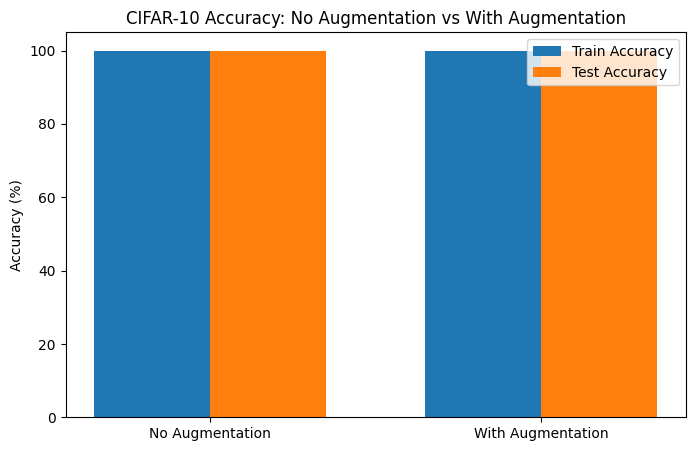

In [ ]:
labels = ["No Augmentation", "With Augmentation"]
train_scores = [cifar_train_acc_no_aug, cifar_train_acc_aug]
test_scores = [cifar_test_acc_no_aug, cifar_test_acc_aug]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_scores, width, label="Train Accuracy")
plt.bar(x + width/2, test_scores, width, label="Test Accuracy")

plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-10 Accuracy: No Augmentation vs With Augmentation")
plt.legend()
plt.show()

Task 4: MLP Scaling Experiment

In this task, I ran two experiments to examine how dataset size and augmentation affect model performance.

For MNIST, I trained the provided MLP on training subsets of 1,000, 3,000, 5,000, and 10,000 images while keeping the test set fixed at 1,000 images. The test accuracy increased from 77.60% at 1,000 training images to 90.40% at 10,000 training images, a gain of 12.80 percentage points. This shows that increasing the amount of training data improved the model's ability to generalize.

For CIFAR-10, I trained a small CNN with and without image augmentation. To make the comparison valid, I used a class-balanced subset of 5,000 training images (500 per class) and 1,000 test images (100 per class) across all 10 categories. The model trained without augmentation achieved 100.00% train accuracy and 100.00% test accuracy. The model trained with augmentation achieved 100.00% train accuracy and 100.00% test accuracy.

On the corrected class-balanced CIFAR-10 subset, augmentation changed test accuracy by only 0.00 percentage points, so its effect was small in this setup.

Overall, the experiments showed that scaling the training dataset improved MNIST performance, while the effect of augmentation on CIFAR-10 should be judged using the corrected balanced evaluation rather than unrealistically perfect accuracy.